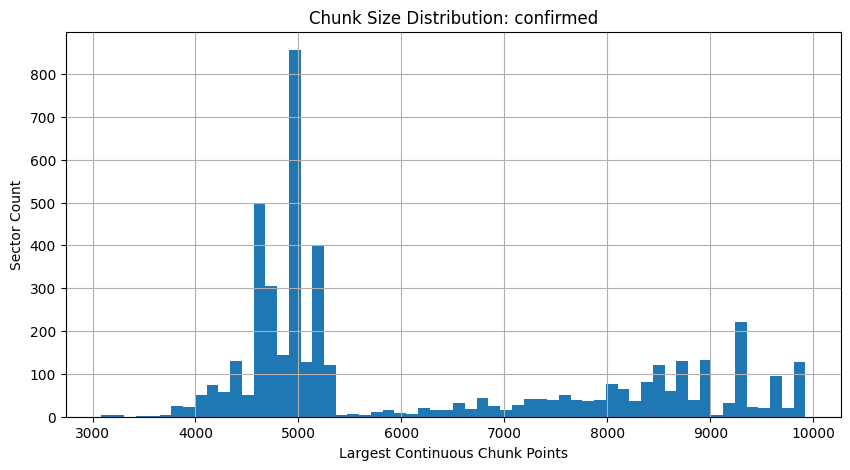

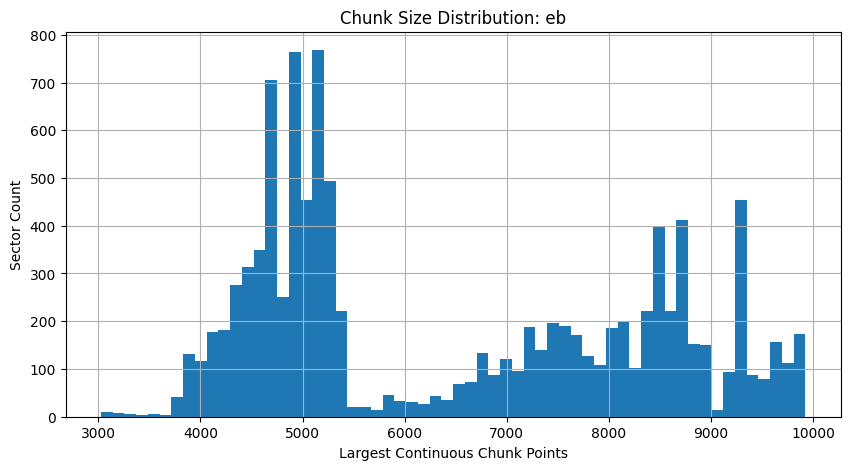

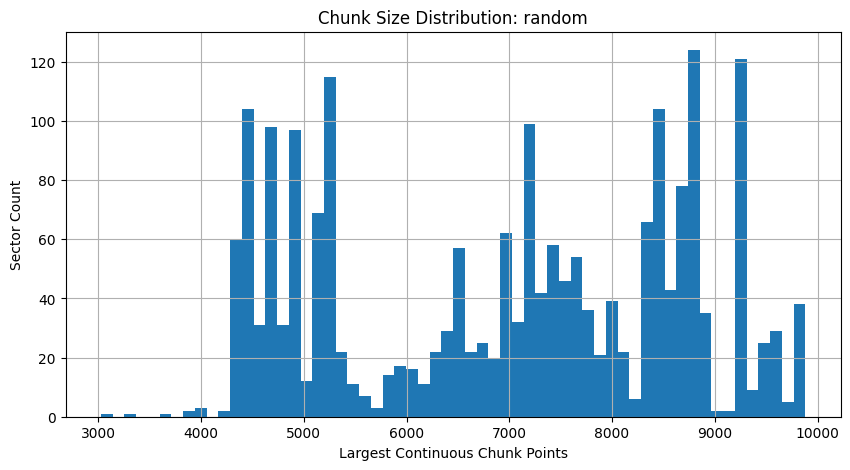

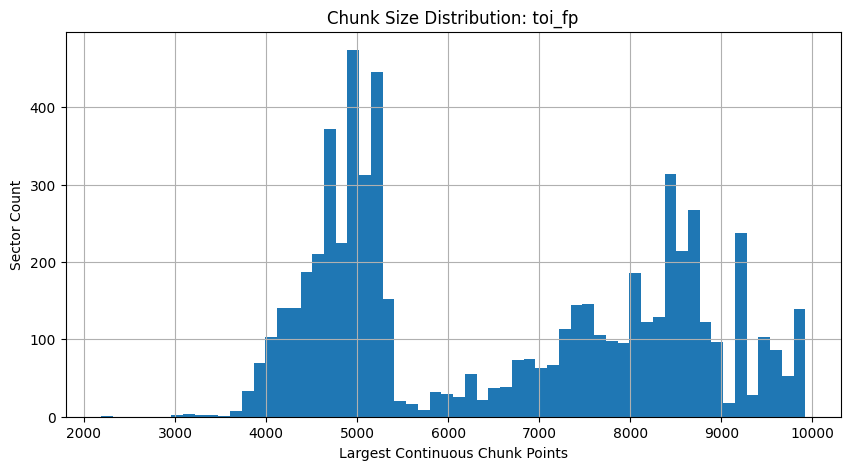

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(
    "largest_chunk_statistics.csv"
)


# ============================================================
# DATASETS
# ============================================================

datasets = sorted(
    df["dataset"].unique()
)


# ============================================================
# HISTOGRAMS
# ============================================================

for dataset_name in datasets:

    subset = df[
        df["dataset"] == dataset_name
    ]

    plt.figure(figsize=(10, 5))

    plt.hist(
        subset["chunk_points"],
        bins=60
    )

    plt.title(
        f"Chunk Size Distribution: {dataset_name}"
    )

    plt.xlabel(
        "Largest Continuous Chunk Points"
    )

    plt.ylabel(
        "Sector Count"
    )

    plt.grid(True)

    plt.show()

100%|██████████| 4721/4721 [01:55<00:00, 40.76it/s]



TRANSIT CADENCE STATS
count    4721.000000
mean       93.479886
std        54.588257
min         3.998924
25%        59.058863
50%        82.858762
75%       120.359824
max       720.309392
Name: cadences_per_transit, dtype: float64

EXPECTED TRANSITS
count    4721.000000
mean        7.875232
std        11.309081
min         0.065511
25%         2.066486
50%         4.877508
75%         8.313167
max       159.420891
Name: expected_transits, dtype: float64

LARGEST CHUNK
count    4721.000000
mean     6194.619784
std      1877.556406
min      3081.000000
25%      4721.000000
50%      5145.000000
75%      8134.000000
max      9924.000000
Name: largest_chunk_points, dtype: float64


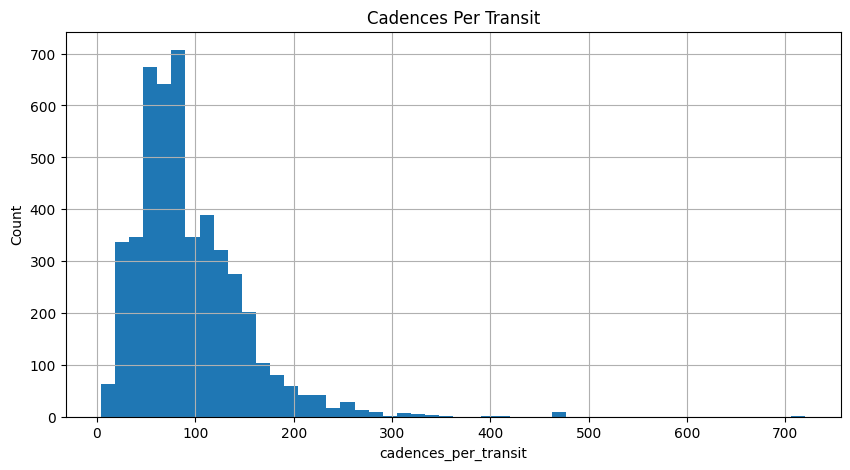

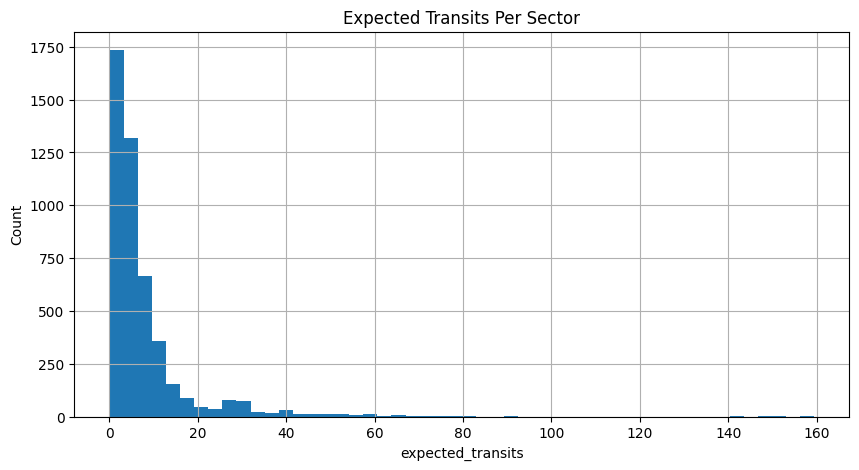

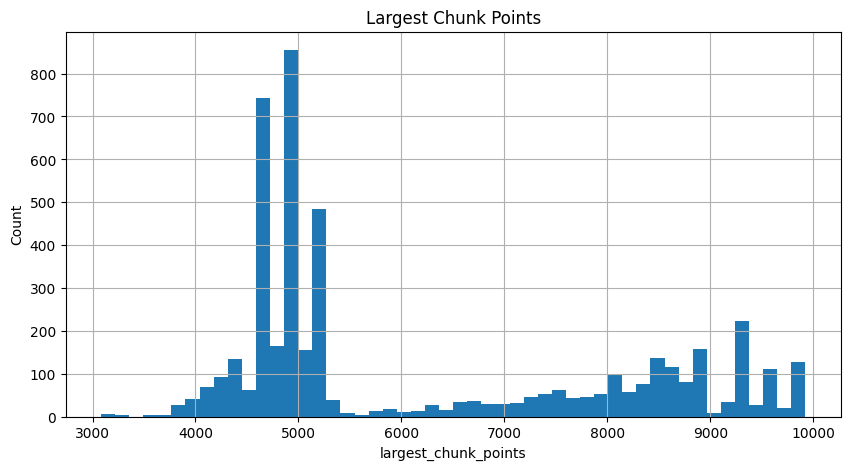


QUANTILES

cadences_per_transit
0.01     15.820919
0.05     27.924432
0.10     36.744029
0.25     59.058863
0.50     82.858762
0.75    120.359824
0.90    156.124138
0.95    190.354365
0.99    270.091824
Name: cadences_per_transit, dtype: float64

expected_transits
0.01     0.362198
0.05     0.882664
0.10     1.178661
0.25     2.066486
0.50     4.877508
0.75     8.313167
0.90    16.672540
0.95    28.780090
0.99    55.367252
Name: expected_transits, dtype: float64

largest_chunk_points
0.01    3945.0
0.05    4302.0
0.10    4596.0
0.25    4721.0
0.50    5145.0
0.75    8134.0
0.90    9245.0
0.95    9598.0
0.99    9882.0
Name: largest_chunk_points, dtype: float64


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from astropy.io import fits


# ============================================================
# CONFIG
# ============================================================

PLANET_CSV = "final_confirmed_planets.csv"

USABLE_SECTORS_CSV = (
    "confirmed_planet_usable_sectors.csv"
)

TESS_ARCHIVE = (
    r"C:\Users\aasha\OneDrive\Desktop\correction\tess_archive"
)

GAP_THRESHOLD_DAYS = 0.02


# ============================================================
# LOAD
# ============================================================

planet_df = pd.read_csv(
    PLANET_CSV
)

usable_df = pd.read_csv(
    USABLE_SECTORS_CSV
)


# ============================================================
# STORAGE
# ============================================================

rows = []


# ============================================================
# MAIN
# ============================================================

for _, row in tqdm(
    usable_df.iterrows(),
    total=len(usable_df)
):

    try:

        tic_id = int(row["tic_id"])

        sector = int(row["sector"])

        fits_file = row["fits_file"]

        # ----------------------------------------------------
        # PLANET INFO
        # ----------------------------------------------------

        planet_rows = planet_df[
            planet_df["tic_id"] == tic_id
        ]

        if len(planet_rows) == 0:
            continue

        planet_info = (
            planet_rows.iloc[0]
        )

        period = float(
            planet_info["period"]
        )

        duration_hours = float(
            planet_info["duration"]
        )

        t0_bjd = float(
            planet_info["t0"]
        )

        # ----------------------------------------------------
        # FITS
        # ----------------------------------------------------

        fits_path = os.path.join(
            TESS_ARCHIVE,
            f"TIC_{tic_id}",
            fits_file
        )

        if not os.path.exists(fits_path):
            continue

        with fits.open(fits_path) as hdul:

            data = hdul[1].data

            time = data["TIME"]

            flux = data["PDCSAP_FLUX"]

        # ----------------------------------------------------
        # VALID
        # ----------------------------------------------------

        valid = (
            np.isfinite(time)
            &
            np.isfinite(flux)
        )

        time = time[valid]

        flux = flux[valid]

        if len(time) < 2:
            continue

        # ----------------------------------------------------
        # SORT
        # ----------------------------------------------------

        order = np.argsort(time)

        time = time[order]

        # ----------------------------------------------------
        # GAPS
        # ----------------------------------------------------

        gaps = np.diff(time)

        break_idxs = np.where(
            gaps > GAP_THRESHOLD_DAYS
        )[0]

        split_points = (
            break_idxs + 1
        )

        time_chunks = np.split(
            time,
            split_points
        )

        # ----------------------------------------------------
        # CHUNK STATS
        # ----------------------------------------------------

        chunk_lengths = [
            len(c)
            for c in time_chunks
        ]

        largest_chunk = max(
            chunk_lengths
        )

        # ----------------------------------------------------
        # CADENCE
        # ----------------------------------------------------

        cadence_days = np.median(
            np.diff(time)
        )

        cadence_minutes = (
            cadence_days
            *
            24
            *
            60
        )

        # ----------------------------------------------------
        # TRANSIT CADENCES
        # ----------------------------------------------------

        duration_minutes = (
            duration_hours * 60
        )

        cadences_per_transit = (
            duration_minutes
            /
            cadence_minutes
        )

        # ----------------------------------------------------
        # SECTOR DURATION
        # ----------------------------------------------------

        sector_duration_days = (
            time.max()
            -
            time.min()
        )

        # ----------------------------------------------------
        # EXPECTED TRANSITS
        # ----------------------------------------------------

        expected_transits = (
            sector_duration_days
            /
            period
        )

        # ----------------------------------------------------
        # STORE
        # ----------------------------------------------------

        rows.append({

            "tic_id":
                tic_id,

            "sector":
                sector,

            "period_days":
                period,

            "duration_hours":
                duration_hours,

            "cadence_minutes":
                cadence_minutes,

            "cadences_per_transit":
                cadences_per_transit,

            "sector_duration_days":
                sector_duration_days,

            "expected_transits":
                expected_transits,

            "largest_chunk_points":
                largest_chunk,

            "num_chunks":
                len(time_chunks)
        })

    except Exception as e:

        print(
            "ERROR:",
            e
        )


# ============================================================
# DATAFRAME
# ============================================================

stats_df = pd.DataFrame(rows)

stats_df.to_csv(
    "transit_window_analysis.csv",
    index=False
)


# ============================================================
# SUMMARY
# ============================================================

print("\n===================================")
print("TRANSIT CADENCE STATS")
print("===================================")

print(
    stats_df[
        "cadences_per_transit"
    ].describe()
)

print("\n===================================")
print("EXPECTED TRANSITS")
print("===================================")

print(
    stats_df[
        "expected_transits"
    ].describe()
)

print("\n===================================")
print("LARGEST CHUNK")
print("===================================")

print(
    stats_df[
        "largest_chunk_points"
    ].describe()
)


# ============================================================
# HISTOGRAMS
# ============================================================

plots = [

    (
        "cadences_per_transit",
        "Cadences Per Transit"
    ),

    (
        "expected_transits",
        "Expected Transits Per Sector"
    ),

    (
        "largest_chunk_points",
        "Largest Chunk Points"
    )
]

for col, title in plots:

    plt.figure(figsize=(10, 5))

    plt.hist(
        stats_df[col],
        bins=50
    )

    plt.title(title)

    plt.xlabel(col)

    plt.ylabel("Count")

    plt.grid(True)

    plt.show()


# ============================================================
# IMPORTANT QUANTILES
# ============================================================

print("\n===================================")
print("QUANTILES")
print("===================================")

for col in [

    "cadences_per_transit",

    "expected_transits",

    "largest_chunk_points"
]:

    print(f"\n{col}")

    print(
        stats_df[col].quantile([
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ])
    )

In [4]:
import os
import csv
import numpy as np
import pandas as pd

from tqdm import tqdm
from astropy.io import fits


# ============================================================
# CONFIG
# ============================================================

TESS_ARCHIVE = (
    r"C:\Users\aasha\OneDrive\Desktop\correction\tess_archive"
)

PLANET_CSV = (
    "final_confirmed_planets.csv"
)

CONFIRMED_SECTORS_CSV = (
    "confirmed_planet_usable_sectors.csv"
)

NEGATIVE_DATASETS = [

    ("final_toi_false_positives.csv", "toi_fp"),

    ("final_eclipsing_binaries.csv", "eb"),

    ("final_random_noisy_stars.csv", "random")
]

OUTPUT_CSV = (
    "tess_sequence_dataset.csv"
)


# ============================================================
# PARAMETERS
# ============================================================

WINDOW_SIZE = 1024

STRIDE = 256

SEQUENCE_LENGTH = 3

CENTER_INDEX = 1

GAP_THRESHOLD_DAYS = 0.02

MIN_CHUNK_POINTS = (
    WINDOW_SIZE
    +
    (SEQUENCE_LENGTH - 1) * STRIDE
)

MAX_SECTORS_PER_TIC = 3


# ============================================================
# LOAD PLANET INFO
# ============================================================

planet_df = pd.read_csv(
    PLANET_CSV
)

planet_df["tic_id"] = (
    planet_df["tic_id"]
    .astype(int)
)

planet_map = {

    row["tic_id"]: row

    for _, row in planet_df.iterrows()
}


# ============================================================
# CSV HEADER
# ============================================================

csv_header = [

    "tic_id",

    "sector",

    "chunk_id",

    "sequence_id",

    "label",

    "window_start_btjd",

    "window_end_btjd"
]

for seq_i in range(SEQUENCE_LENGTH):

    for flux_i in range(WINDOW_SIZE):

        csv_header.append(

            f"seq{seq_i}_flux_{flux_i}"
        )


csv_file = open(

    OUTPUT_CSV,

    "w",

    newline=""
)

csv_writer = csv.writer(
    csv_file
)

csv_writer.writerow(
    csv_header
)


# ============================================================
# COUNTERS
# ============================================================

total_samples = 0

positive_samples = 0

negative_samples = 0


# ============================================================
# NORMALIZATION
# ============================================================

def normalize_flux(flux):

    median_flux = np.median(flux)

    if median_flux == 0:
        return None

    flux = flux / median_flux

    flux = (
        flux - np.mean(flux)
    ) / (
        np.std(flux) + 1e-8
    )

    return flux.astype(np.float32)


# ============================================================
# SPLIT CONTINUOUS CHUNKS
# ============================================================

def split_continuous_chunks(
    time,
    flux
):

    valid = (

        np.isfinite(time)

        &

        np.isfinite(flux)
    )

    time = time[valid]

    flux = flux[valid]

    if len(time) < 2:
        return []

    order = np.argsort(time)

    time = time[order]

    flux = flux[order]

    gaps = np.diff(time)

    break_idxs = np.where(
        gaps > GAP_THRESHOLD_DAYS
    )[0]

    split_points = (
        break_idxs + 1
    )

    time_chunks = np.split(
        time,
        split_points
    )

    flux_chunks = np.split(
        flux,
        split_points
    )

    chunks = []

    for t_chunk, f_chunk in zip(
        time_chunks,
        flux_chunks
    ):

        if len(t_chunk) < MIN_CHUNK_POINTS:
            continue

        chunks.append(
            (t_chunk, f_chunk)
        )

    return chunks


# ============================================================
# TRANSIT CHECK
# ============================================================

def full_transit_inside_window(

    window_start,
    window_end,

    period,
    t0_btjd,
    duration_days
):

    n_start = int(
        np.floor(
            (window_start - t0_btjd)
            /
            period
        )
    ) - 1

    n_end = int(
        np.ceil(
            (window_end - t0_btjd)
            /
            period
        )
    ) + 1

    for n in range(
        n_start,
        n_end + 1
    ):

        transit_center = (
            t0_btjd
            +
            n * period
        )

        transit_start = (
            transit_center
            -
            duration_days / 2
        )

        transit_end = (
            transit_center
            +
            duration_days / 2
        )

        if (

            window_start
            <=
            transit_start

            and

            window_end
            >=
            transit_end
        ):

            return True

    return False


# ============================================================
# WRITE SAMPLE
# ============================================================

def write_sequence(

    tic_id,
    sector,
    chunk_id,
    sequence_id,
    label,

    sequence_flux,

    window_start,
    window_end
):

    global total_samples
    global positive_samples
    global negative_samples

    row = [

        tic_id,

        sector,

        chunk_id,

        sequence_id,

        label,

        window_start,

        window_end
    ]

    for seq_flux in sequence_flux:

        row.extend(
            seq_flux
        )

    csv_writer.writerow(row)

    total_samples += 1

    if label == 1:
        positive_samples += 1
    else:
        negative_samples += 1


# ============================================================
# BUILD WINDOW LIST
# ============================================================

def build_windows(
    t_chunk,
    f_chunk
):

    windows = []

    n_windows = (

        (
            len(t_chunk)
            -
            WINDOW_SIZE
        )
        //
        STRIDE
    ) + 1

    for w in range(n_windows):

        start_idx = (
            w * STRIDE
        )

        end_idx = (
            start_idx
            +
            WINDOW_SIZE
        )

        window_flux = (
            f_chunk[
                start_idx:end_idx
            ]
        )

        window_time = (
            t_chunk[
                start_idx:end_idx
            ]
        )

        if (
            len(window_flux)
            !=
            WINDOW_SIZE
        ):
            continue

        norm_flux = normalize_flux(
            window_flux
        )

        if norm_flux is None:
            continue

        windows.append({

            "window_id":
                w,

            "flux":
                norm_flux,

            "time":
                window_time
        })

    return windows


# ============================================================
# PROCESS CONFIRMED PLANETS
# ============================================================

print("\n===================================")
print("PROCESSING CONFIRMED PLANETS")
print("===================================")

usable_df = pd.read_csv(
    CONFIRMED_SECTORS_CSV
)

usable_df["tic_id"] = (
    usable_df["tic_id"]
    .astype(int)
)

grouped = usable_df.groupby(
    "tic_id"
)

for tic_id, tic_group in tqdm(grouped):

    if tic_id not in planet_map:
        continue

    planet_info = planet_map[tic_id]

    period = float(
        planet_info["period"]
    )

    t0_btjd = (
        float(planet_info["t0"])
        - 2457000
    )

    duration_days = (
        float(
            planet_info["duration"]
        )
        / 24.0
    )

    for _, row in tic_group.iterrows():

        sector = int(
            row["sector"]
        )

        fits_file = row[
            "fits_file"
        ]

        fits_path = os.path.join(

            TESS_ARCHIVE,

            f"TIC_{tic_id}",

            fits_file
        )

        if not os.path.exists(fits_path):
            continue

        try:

            with fits.open(fits_path) as hdul:

                data = hdul[1].data

                time = data["TIME"]

                flux = data[
                    "PDCSAP_FLUX"
                ]

            chunks = split_continuous_chunks(
                time,
                flux
            )

            for chunk_id, (
                t_chunk,
                f_chunk
            ) in enumerate(chunks):

                windows = build_windows(
                    t_chunk,
                    f_chunk
                )

                if (
                    len(windows)
                    <
                    SEQUENCE_LENGTH
                ):
                    continue

                for seq_start in range(

                    len(windows)
                    -
                    SEQUENCE_LENGTH
                    +
                    1
                ):

                    seq_windows = windows[

                        seq_start:
                        seq_start
                        +
                        SEQUENCE_LENGTH
                    ]

                    center_window = (
                        seq_windows[
                            CENTER_INDEX
                        ]
                    )

                    center_time = (
                        center_window[
                            "time"
                        ]
                    )

                    label = int(

                        full_transit_inside_window(

                            center_time.min(),

                            center_time.max(),

                            period,
                            t0_btjd,
                            duration_days
                        )
                    )

                    if label != 1:
                        continue

                    sequence_flux = [

                        w["flux"]

                        for w in seq_windows
                    ]

                    write_sequence(

                        tic_id,
                        sector,
                        chunk_id,
                        seq_start,
                        label,

                        sequence_flux,

                        center_time.min(),
                        center_time.max()
                    )

        except Exception as e:

            print(
                "ERROR:",
                tic_id,
                sector,
                e
            )


# ============================================================
# PROCESS NEGATIVES
# ============================================================

print("\n===================================")
print("PROCESSING NEGATIVES")
print("===================================")

for neg_csv, neg_name in NEGATIVE_DATASETS:

    print("\n---", neg_name, "---")

    neg_df = pd.read_csv(
        neg_csv
    )

    grouped = neg_df.groupby(
        "tic_id"
    )

    for tic_id, tic_group in tqdm(grouped):

        tic_id = int(tic_id)

        tic_dir = os.path.join(

            TESS_ARCHIVE,

            f"TIC_{tic_id}"
        )

        if not os.path.exists(tic_dir):
            continue

        fits_files = [

            f for f in os.listdir(
                tic_dir
            )

            if f.endswith(".fits")
        ]

        for fits_file in fits_files:

            fits_path = os.path.join(
                tic_dir,
                fits_file
            )

            try:

                with fits.open(fits_path) as hdul:

                    sector = int(
                        hdul[0]
                        .header["SECTOR"]
                    )

                    data = hdul[1].data

                    time = data["TIME"]

                    flux = data[
                        "PDCSAP_FLUX"
                    ]

                chunks = split_continuous_chunks(
                    time,
                    flux
                )

                for chunk_id, (
                    t_chunk,
                    f_chunk
                ) in enumerate(chunks):

                    windows = build_windows(
                        t_chunk,
                        f_chunk
                    )

                    if (
                        len(windows)
                        <
                        SEQUENCE_LENGTH
                    ):
                        continue

                    for seq_start in range(

                        len(windows)
                        -
                        SEQUENCE_LENGTH
                        +
                        1
                    ):

                        seq_windows = windows[

                            seq_start:
                            seq_start
                            +
                            SEQUENCE_LENGTH
                        ]

                        center_window = (
                            seq_windows[
                                CENTER_INDEX
                            ]
                        )

                        center_time = (
                            center_window[
                                "time"
                            ]
                        )

                        sequence_flux = [

                            w["flux"]

                            for w in seq_windows
                        ]

                        write_sequence(

                            tic_id,
                            sector,
                            chunk_id,
                            seq_start,
                            0,

                            sequence_flux,

                            center_time.min(),
                            center_time.max()
                        )

            except Exception:
                pass


# ============================================================
# CLOSE
# ============================================================

csv_file.close()

print("\n===================================")
print("DONE")
print("===================================")

print(
    "\nTotal samples:",
    total_samples
)

print(
    "\nPositive samples:",
    positive_samples
)

print(
    "\nNegative samples:",
    negative_samples
)

print(
    "\nSaved:",
    OUTPUT_CSV
)


PROCESSING CONFIRMED PLANETS


100%|██████████| 900/900 [03:39<00:00,  4.10it/s]



PROCESSING NEGATIVES

--- toi_fp ---


100%|██████████| 1333/1333 [10:39<00:00,  2.08it/s]



--- eb ---


100%|██████████| 1400/1400 [18:27<00:00,  1.26it/s]



--- random ---


100%|██████████| 1400/1400 [04:13<00:00,  5.53it/s]


DONE

Total samples: 898254

Positive samples: 52243

Negative samples: 846011

Saved: tess_sequence_dataset.csv


In [5]:
import os
import csv
import numpy as np
import pandas as pd

from tqdm import tqdm
from astropy.io import fits
from scipy.ndimage import median_filter


# ============================================================
# CONFIG
# ============================================================

TESS_ARCHIVE = (
    r"C:\Users\aasha\OneDrive\Desktop\correction\tess_archive"
)

PLANET_CSV = (
    "final_confirmed_planets.csv"
)

NEGATIVE_DATASETS = [

    ("final_toi_false_positives.csv", "toi_fp"),

    ("final_eclipsing_binaries.csv", "eb"),

    ("final_random_noisy_stars.csv", "random")
]

OUTPUT_CSV = (
    "tess_candidate_dataset.csv"
)


# ============================================================
# PARAMETERS
# ============================================================

WINDOW_SIZE = 1024

LOCAL_DETREND_KERNEL = 401

MIN_CHUNK_POINTS = 3000

GAP_THRESHOLD_DAYS = 0.02

MAX_CANDIDATES_PER_CHUNK = 20

DEPTH_SIGMA_THRESHOLD = 3.0


# ============================================================
# LOAD PLANET INFO
# ============================================================

planet_df = pd.read_csv(
    PLANET_CSV
)

planet_df["tic_id"] = (
    planet_df["tic_id"]
    .astype(int)
)

planet_map = {

    row["tic_id"]: row

    for _, row in planet_df.iterrows()
}


# ============================================================
# CSV HEADER
# ============================================================

csv_header = [

    "tic_id",

    "sector",

    "chunk_id",

    "candidate_id",

    "label",

    "candidate_center_btjd",

    "candidate_depth",

    "candidate_snr"
]

for i in range(WINDOW_SIZE):

    csv_header.append(
        f"flux_{i}"
    )


csv_file = open(

    OUTPUT_CSV,

    "w",

    newline=""
)

csv_writer = csv.writer(
    csv_file
)

csv_writer.writerow(
    csv_header
)


# ============================================================
# COUNTERS
# ============================================================

total_samples = 0

positive_samples = 0

negative_samples = 0


# ============================================================
# NORMALIZATION
# ============================================================

def normalize_flux(

    flux
):

    median_flux = np.median(
        flux
    )

    if median_flux == 0:
        return None

    flux = (
        flux / median_flux
    )

    return flux.astype(
        np.float32
    )


# ============================================================
# SPLIT CONTINUOUS CHUNKS
# ============================================================

def split_continuous_chunks(

    time,
    flux
):

    valid = (

        np.isfinite(time)

        &

        np.isfinite(flux)
    )

    time = time[valid]

    flux = flux[valid]

    if len(time) < 2:
        return []

    order = np.argsort(
        time
    )

    time = time[order]

    flux = flux[order]

    gaps = np.diff(time)

    break_idxs = np.where(

        gaps > GAP_THRESHOLD_DAYS

    )[0]

    split_points = (
        break_idxs + 1
    )

    time_chunks = np.split(

        time,
        split_points
    )

    flux_chunks = np.split(

        flux,
        split_points
    )

    chunks = []

    for t_chunk, f_chunk in zip(

        time_chunks,
        flux_chunks
    ):

        if (
            len(t_chunk)
            <
            MIN_CHUNK_POINTS
        ):
            continue

        chunks.append(
            (t_chunk, f_chunk)
        )

    return chunks


# ============================================================
# DETREND
# ============================================================

def detrend_flux(

    flux
):

    trend = median_filter(

        flux,

        size=LOCAL_DETREND_KERNEL,

        mode="nearest"
    )

    detrended = (
        flux / trend
    )

    return detrended


# ============================================================
# CANDIDATE DETECTION
# ============================================================

def detect_candidates(

    time,
    flux
):

    detrended = detrend_flux(
        flux
    )

    residual = (
        detrended
        -
        np.median(detrended)
    )

    sigma = np.std(
        residual
    )

    threshold = (
        -DEPTH_SIGMA_THRESHOLD
        * sigma
    )

    candidate_idxs = np.where(
        residual < threshold
    )[0]

    if len(candidate_idxs) == 0:
        return []

    grouped = []

    current_group = [
        candidate_idxs[0]
    ]

    for idx in candidate_idxs[1:]:

        if (
            idx
            -
            current_group[-1]
            <= 10
        ):

            current_group.append(
                idx
            )

        else:

            grouped.append(
                current_group
            )

            current_group = [idx]

    grouped.append(
        current_group
    )

    candidates = []

    for group in grouped:

        center_idx = group[
            np.argmin(
                flux[group]
            )
        ]

        depth = (
            np.median(flux)
            -
            flux[center_idx]
        )

        snr = (
            depth
            /
            (sigma + 1e-8)
        )

        candidates.append({

            "center_idx":
                center_idx,

            "depth":
                depth,

            "snr":
                snr
        })

    candidates = sorted(

        candidates,

        key=lambda x: x["snr"],

        reverse=True
    )

    return candidates[
        :MAX_CANDIDATES_PER_CHUNK
    ]


# ============================================================
# TRANSIT LABEL
# ============================================================

def candidate_contains_transit(

    candidate_time,

    period,
    t0_btjd,
    duration_days
):

    n_start = int(

        np.floor(

            (
                candidate_time
                -
                duration_days
                -
                t0_btjd
            )
            /
            period
        )

    ) - 1

    n_end = int(

        np.ceil(

            (
                candidate_time
                +
                duration_days
                -
                t0_btjd
            )
            /
            period
        )

    ) + 1

    for n in range(

        n_start,
        n_end + 1
    ):

        transit_center = (

            t0_btjd
            +
            n * period
        )

        if (

            abs(
                candidate_time
                -
                transit_center
            )

            <=

            duration_days
        ):

            return True

    return False


# ============================================================
# WRITE SAMPLE
# ============================================================

def write_sample(

    tic_id,
    sector,
    chunk_id,
    candidate_id,

    label,

    candidate_center_btjd,

    candidate_depth,

    candidate_snr,

    flux_window
):

    global total_samples
    global positive_samples
    global negative_samples

    row = [

        tic_id,

        sector,

        chunk_id,

        candidate_id,

        label,

        candidate_center_btjd,

        candidate_depth,

        candidate_snr
    ]

    row.extend(
        flux_window
    )

    csv_writer.writerow(
        row
    )

    total_samples += 1

    if label == 1:

        positive_samples += 1

    else:

        negative_samples += 1


# ============================================================
# PROCESS PLANETS
# ============================================================

print("\n===================================")
print("PROCESSING PLANETS")
print("===================================")

planet_groups = planet_df.groupby(
    "tic_id"
)

for tic_id, group in tqdm(
    planet_groups
):

    tic_dir = os.path.join(

        TESS_ARCHIVE,

        f"TIC_{tic_id}"
    )

    if not os.path.exists(
        tic_dir
    ):
        continue

    period = float(
        group.iloc[0]["period"]
    )

    t0_btjd = (

        float(
            group.iloc[0]["t0"]
        )
        -
        2457000
    )

    duration_days = (

        float(
            group.iloc[0]["duration"]
        )
        / 24.0
    )

    fits_files = [

        f for f in os.listdir(
            tic_dir
        )

        if f.endswith(".fits")
    ]

    for fits_file in fits_files:

        fits_path = os.path.join(

            tic_dir,
            fits_file
        )

        try:

            with fits.open(
                fits_path
            ) as hdul:

                sector = int(

                    hdul[0]
                    .header["SECTOR"]
                )

                data = hdul[1].data

                time = data["TIME"]

                flux = data[
                    "PDCSAP_FLUX"
                ]

            chunks = split_continuous_chunks(

                time,
                flux
            )

            for chunk_id, (
                t_chunk,
                f_chunk
            ) in enumerate(chunks):

                norm_flux = normalize_flux(
                    f_chunk
                )

                if norm_flux is None:
                    continue

                candidates = detect_candidates(

                    t_chunk,
                    norm_flux
                )

                for candidate_id, candidate in enumerate(candidates):

                    center_idx = candidate[
                        "center_idx"
                    ]

                    half_window = (
                        WINDOW_SIZE // 2
                    )

                    start_idx = (
                        center_idx
                        -
                        half_window
                    )

                    end_idx = (
                        center_idx
                        +
                        half_window
                    )

                    if (
                        start_idx < 0
                        or
                        end_idx >= len(norm_flux)
                    ):
                        continue

                    flux_window = norm_flux[
                        start_idx:end_idx
                    ]

                    if (
                        len(flux_window)
                        != WINDOW_SIZE
                    ):
                        continue

                    candidate_time = t_chunk[
                        center_idx
                    ]

                    label = int(

                        candidate_contains_transit(

                            candidate_time,

                            period,
                            t0_btjd,
                            duration_days
                        )
                    )

                    write_sample(

                        tic_id,
                        sector,
                        chunk_id,
                        candidate_id,

                        label,

                        candidate_time,

                        candidate["depth"],

                        candidate["snr"],

                        flux_window
                    )

        except Exception:
            pass


# ============================================================
# PROCESS NEGATIVES
# ============================================================

print("\n===================================")
print("PROCESSING NEGATIVES")
print("===================================")

for neg_csv, neg_name in NEGATIVE_DATASETS:

    print("\n---", neg_name, "---")

    neg_df = pd.read_csv(
        neg_csv
    )

    grouped = neg_df.groupby(
        "tic_id"
    )

    for tic_id, group in tqdm(grouped):

        tic_id = int(
            tic_id
        )

        tic_dir = os.path.join(

            TESS_ARCHIVE,

            f"TIC_{tic_id}"
        )

        if not os.path.exists(
            tic_dir
        ):
            continue

        fits_files = [

            f for f in os.listdir(
                tic_dir
            )

            if f.endswith(".fits")
        ]

        for fits_file in fits_files:

            fits_path = os.path.join(

                tic_dir,
                fits_file
            )

            try:

                with fits.open(
                    fits_path
                ) as hdul:

                    sector = int(

                        hdul[0]
                        .header["SECTOR"]
                    )

                    data = hdul[1].data

                    time = data["TIME"]

                    flux = data[
                        "PDCSAP_FLUX"
                    ]

                chunks = split_continuous_chunks(

                    time,
                    flux
                )

                for chunk_id, (
                    t_chunk,
                    f_chunk
                ) in enumerate(chunks):

                    norm_flux = normalize_flux(
                        f_chunk
                    )

                    if norm_flux is None:
                        continue

                    candidates = detect_candidates(

                        t_chunk,
                        norm_flux
                    )

                    for candidate_id, candidate in enumerate(candidates):

                        center_idx = candidate[
                            "center_idx"
                        ]

                        half_window = (
                            WINDOW_SIZE // 2
                        )

                        start_idx = (
                            center_idx
                            -
                            half_window
                        )

                        end_idx = (
                            center_idx
                            +
                            half_window
                        )

                        if (
                            start_idx < 0
                            or
                            end_idx >= len(norm_flux)
                        ):
                            continue

                        flux_window = norm_flux[
                            start_idx:end_idx
                        ]

                        if (
                            len(flux_window)
                            != WINDOW_SIZE
                        ):
                            continue

                        candidate_time = t_chunk[
                            center_idx
                        ]

                        write_sample(

                            tic_id,
                            sector,
                            chunk_id,
                            candidate_id,

                            0,

                            candidate_time,

                            candidate["depth"],

                            candidate["snr"],

                            flux_window
                        )

            except Exception:
                pass


# ============================================================
# CLOSE
# ============================================================

csv_file.close()


# ============================================================
# FINAL STATS
# ============================================================

print("\n===================================")
print("DONE")
print("===================================")

print(
    "\nTotal samples:",
    total_samples
)

print(
    "\nPositive samples:",
    positive_samples
)

print(
    "\nNegative samples:",
    negative_samples
)

print(
    "\nSaved:",
    OUTPUT_CSV
)


PROCESSING PLANETS


100%|██████████| 994/994 [03:04<00:00,  5.39it/s]



PROCESSING NEGATIVES

--- toi_fp ---


100%|██████████| 1333/1333 [04:11<00:00,  5.31it/s]



--- eb ---


100%|██████████| 1400/1400 [06:28<00:00,  3.61it/s]



--- random ---


100%|██████████| 1400/1400 [01:00<00:00, 23.33it/s] 


DONE

Total samples: 227443

Positive samples: 9656

Negative samples: 217787

Saved: tess_candidate_dataset.csv


In [1]:
# ============================================================
# CHUNK-LEVEL PLANET SYSTEM CLASSIFIER
# WINDOWS + DIRECTML VERIFIED VERSION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

import torch
import torch.nn as nn
import torch_directml

from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler
)

from tqdm import tqdm


# ============================================================
# CONFIG
# ============================================================

DATASET_CSV = (
    r"C:\Users\aasha\OneDrive\Desktop\correction\tess_chunk_system_dataset.csv"
)

BATCH_SIZE = 128

EPOCHS = 50

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

PATIENCE = 7

RANDOM_STATE = 42


# ============================================================
# DEVICE
# ============================================================

device = torch_directml.device()

print("\n===================================")
print("DEVICE")
print("===================================")
print(device)


# ============================================================
# LOAD DATASET
# ============================================================

print("\n===================================")
print("LOADING DATASET")
print("===================================")

df = pd.read_csv(
    DATASET_CSV
)

print(df.shape)

print("\nLabel distribution:")
print(
    df["label"].value_counts()
)


# ============================================================
# FEATURES
# ============================================================

flux_cols = [

    c for c in df.columns

    if c.startswith("flux_")
]

X = df[flux_cols].values.astype(
    np.float32
)

y = df["label"].values.astype(
    np.float32
)


# ============================================================
# TRAIN / VALIDATION / TEST
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(

    X,
    y,

    test_size=0.25,

    stratify=y,

    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(

    X_temp,
    y_temp,

    test_size=0.5,

    stratify=y_temp,

    random_state=RANDOM_STATE
)

print("\n===================================")
print("TRAIN")
print("===================================")

print(X_train.shape)

print(
    pd.Series(y_train).value_counts()
)

print("\n===================================")
print("VALIDATION")
print("===================================")

print(X_val.shape)

print(
    pd.Series(y_val).value_counts()
)

print("\n===================================")
print("TEST")
print("===================================")

print(X_test.shape)

print(
    pd.Series(y_test).value_counts()
)


# ============================================================
# DATASET
# ============================================================

class ChunkDataset(Dataset):

    def __init__(

        self,

        X,
        y
    ):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

    def __len__(self):

        return len(self.X)

    def __getitem__(

        self,
        idx
    ):

        x = self.X[idx].unsqueeze(0)

        y = self.y[idx]

        return x, y


train_dataset = ChunkDataset(
    X_train,
    y_train
)

val_dataset = ChunkDataset(
    X_val,
    y_val
)

test_dataset = ChunkDataset(
    X_test,
    y_test
)


# ============================================================
# BALANCED SAMPLER
# ============================================================

class_counts = np.bincount(
    y_train.astype(int)
)

class_weights = (
    1.0 / class_counts
)

sample_weights = class_weights[
    y_train.astype(int)
]

sampler = WeightedRandomSampler(

    weights=sample_weights,

    num_samples=len(sample_weights),

    replacement=True
)


# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    sampler=sampler,

    num_workers=0,

    pin_memory=False
)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=False
)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=False
)


# ============================================================
# FOCAL LOSS
# ============================================================

criterion = nn.BCEWithLogitsLoss()


# ============================================================
# MODEL
# ============================================================

class ChunkCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv1d(
                1,
                32,
                kernel_size=7,
                padding=3
            ),

            nn.BatchNorm1d(32),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                32,
                64,
                kernel_size=5,
                padding=2
            ),

            nn.BatchNorm1d(64),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                64,
                128,
                kernel_size=5,
                padding=2
            ),

            nn.BatchNorm1d(128),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                128,
                256,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm1d(256),

            nn.ReLU(),

            nn.AdaptiveAvgPool1d(16)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                256 * 16,
                512
            ),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(
                512,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                1
            )
        )

    def forward(

        self,
        x
    ):

        x = self.features(x)

        x = self.classifier(x)

        return x.squeeze(1)


model = ChunkCNN().to(
    device
)


# ============================================================
# OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY
)


# ============================================================
# EVALUATION
# ============================================================

def evaluate(

    model,
    loader
):

    model.eval()

    losses = []

    all_probs = []

    all_labels = []

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)

            y = y.to(device)

            logits = model(x)

            loss = criterion(
                logits,
                y
            )

            probs = torch.sigmoid(
                logits
            )

            losses.append(
                loss.item()
            )

            all_probs.extend(
                probs.cpu().numpy()
            )

            all_labels.extend(
                y.cpu().numpy()
            )

    all_probs = np.array(
        all_probs
    )

    all_labels = np.array(
        all_labels
    )

    preds = (
        all_probs >= 0.5
    ).astype(int)

    precision = precision_score(

        all_labels,
        preds,

        zero_division=0
    )

    recall = recall_score(

        all_labels,
        preds,

        zero_division=0
    )

    f1 = f1_score(

        all_labels,
        preds,

        zero_division=0
    )

    pr_auc = average_precision_score(

        all_labels,
        all_probs
    )

    return {

        "loss":
            np.mean(losses),

        "precision":
            precision,

        "recall":
            recall,

        "f1":
            f1,

        "pr_auc":
            pr_auc
    }


# ============================================================
# TRAINING
# ============================================================

best_pr_auc = 0

epochs_without_improvement = 0

for epoch in range(EPOCHS):

    print("\n===================================")
    print(f"EPOCH {epoch+1}/{EPOCHS}")
    print("===================================")

    model.train()

    train_losses = []

    for x, y in tqdm(train_loader):

        x = x.to(device)

        y = y.to(device)

        optimizer.zero_grad()

        logits = model(x)

        loss = criterion(
            logits,
            y
        )

        loss.backward()

        optimizer.step()

        train_losses.append(
            loss.item()
        )

    print("\nTRAIN LOSS:")
    print(
        np.mean(train_losses)
    )

    metrics = evaluate(

        model,
        val_loader
    )

    print("\nVALIDATION:")

    for k, v in metrics.items():

        print(f"{k}: {v:.6f}")

    if metrics["pr_auc"] > best_pr_auc:

        best_pr_auc = metrics["pr_auc"]

        epochs_without_improvement = 0

        torch.save(

            model.state_dict(),

            "best_chunk_model.pt"
        )

        print("\nBEST MODEL SAVED")

    else:

        epochs_without_improvement += 1

        print(
            f"\nNo improvement ({epochs_without_improvement}/{PATIENCE})"
        )

    if epochs_without_improvement >= PATIENCE:

        print("\nEARLY STOPPING")

        break


# ============================================================
# FINAL TEST
# ============================================================

print("\n===================================")
print("FINAL TEST")
print("===================================")

model.load_state_dict(

    torch.load(

        "best_chunk_model.pt",

        map_location=device
    )
)

test_metrics = evaluate(

    model,
    test_loader
)

for k, v in test_metrics.items():

    print(f"{k}: {v:.6f}")


DEVICE
privateuseone:0

LOADING DATASET
(43963, 1130)

Label distribution:
label
0    34290
1     9673
Name: count, dtype: int64

TRAIN
(32972, 1125)
0.0    25717
1.0     7255
Name: count, dtype: int64

VALIDATION
(5495, 1125)
0.0    4286
1.0    1209
Name: count, dtype: int64

TEST
(5496, 1125)
0.0    4287
1.0    1209
Name: count, dtype: int64

EPOCH 1/50


  0%|          | 0/258 [00:00<?, ?it/s]c:\Users\aasha\miniconda3\envs\torch-dml\lib\site-packages\torch\nn\functional.py:3244: UserWarning: The operator 'aten::log_sigmoid_forward' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  return torch.binary_cross_entropy_with_logits(input, target, weight, pos_weight, reduction_enum)
100%|██████████| 258/258 [01:10<00:00,  3.63it/s]



TRAIN LOSS:
0.5167323643153952

VALIDATION:
loss: 0.433684
precision: 0.841463
recall: 0.171216
f1: 0.284536
pr_auc: 0.599055

BEST MODEL SAVED

EPOCH 2/50


100%|██████████| 258/258 [01:06<00:00,  3.89it/s]



TRAIN LOSS:
0.472719995550407

VALIDATION:
loss: 0.410942
precision: 0.728636
recall: 0.401985
f1: 0.518124
pr_auc: 0.634687

BEST MODEL SAVED

EPOCH 3/50


...


TRAIN LOSS:
0.4136216215385023

VALIDATION:
loss: 2.478075
precision: 0.661538
recall: 0.106700
f1: 0.183761
pr_auc: 0.475473

No improvement (6/7)

EPOCH 10/50


100%|██████████| 258/258 [01:04<00:00,  4.00it/s]



TRAIN LOSS:
0.41048008827276006

VALIDATION:
loss: 2.566683
precision: 0.755486
recall: 0.199338
f1: 0.315445
pr_auc: 0.547203

No improvement (7/7)

EARLY STOPPING

FINAL TEST


C:\Users\aasha\AppData\Local\Temp\ipykernel_19304\812977628.py:629: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


loss: 0.396959
precision: 0.739385
recall: 0.417701
f1: 0.533827
pr_auc: 0.654290


In [1]:
# ============================================================
# ENSEMBLE EXOPLANET DETECTOR
# CUDA + GOOGLE COLAB + GOOGLE DRIVE
# NO UNPICKLING WARNING
# ============================================================

from google.colab import drive

drive.mount('/content/drive')


# ============================================================
# IMPORTS
# ============================================================

import random
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler
)

from tqdm import tqdm


# ============================================================
# CONFIG
# ============================================================

DATASET_CSV = (
    "/content/drive/MyDrive/tess_chunk_system_dataset.csv"
)

MODEL_DIR = (
    "/content/drive/MyDrive/"
)

BATCH_SIZE = 128

EPOCHS = 50

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

PATIENCE = 7


# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("\n===================================")
print("DEVICE")
print("===================================")
print(device)


# ============================================================
# FIXED GLOBAL SEED
# ============================================================

GLOBAL_SEED = 42

random.seed(GLOBAL_SEED)

np.random.seed(GLOBAL_SEED)

torch.manual_seed(GLOBAL_SEED)

torch.cuda.manual_seed_all(GLOBAL_SEED)

torch.backends.cudnn.deterministic = True

torch.backends.cudnn.benchmark = False


# ============================================================
# LOAD DATASET
# ============================================================

print("\n===================================")
print("LOADING DATASET")
print("===================================")

df = pd.read_csv(
    DATASET_CSV
)

print(df.shape)

print("\nLabel distribution:")
print(
    df["label"].value_counts()
)


# ============================================================
# FEATURE COLUMNS
# ============================================================

flux_cols = [

    c for c in df.columns

    if c.startswith("flux_")
]


# ============================================================
# TIC SPLIT
# ============================================================

unique_tics = df[
    "tic_id"
].unique()

train_tics, temp_tics = train_test_split(

    unique_tics,

    test_size=0.25,

    random_state=GLOBAL_SEED
)

val_tics, test_tics = train_test_split(

    temp_tics,

    test_size=0.5,

    random_state=GLOBAL_SEED
)

train_df = df[
    df["tic_id"].isin(train_tics)
]

val_df = df[
    df["tic_id"].isin(val_tics)
]

test_df = df[
    df["tic_id"].isin(test_tics)
]


# ============================================================
# ARRAYS
# ============================================================

X_train = train_df[
    flux_cols
].values.astype(np.float32)

y_train = train_df[
    "label"
].values.astype(np.float32)


X_val = val_df[
    flux_cols
].values.astype(np.float32)

y_val = val_df[
    "label"
].values.astype(np.float32)


X_test = test_df[
    flux_cols
].values.astype(np.float32)

y_test = test_df[
    "label"
].values.astype(np.float32)


# ============================================================
# DATASET
# ============================================================

class ChunkDataset(Dataset):

    def __init__(

        self,

        X,
        y
    ):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

    def __len__(self):

        return len(self.X)

    def __getitem__(

        self,
        idx
    ):

        x = self.X[idx].unsqueeze(0)

        y = self.y[idx]

        return x, y


train_dataset = ChunkDataset(
    X_train,
    y_train
)

val_dataset = ChunkDataset(
    X_val,
    y_val
)

test_dataset = ChunkDataset(
    X_test,
    y_test
)


# ============================================================
# BALANCED SAMPLER
# ============================================================

class_counts = np.bincount(
    y_train.astype(int)
)

class_weights = (
    1.0 / class_counts
)

sample_weights = class_weights[
    y_train.astype(int)
]

sampler = WeightedRandomSampler(

    weights=sample_weights,

    num_samples=len(sample_weights),

    replacement=True
)


# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    sampler=sampler,

    num_workers=2,

    pin_memory=True,

    persistent_workers=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True,

    persistent_workers=True
)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True,

    persistent_workers=True
)


# ============================================================
# MODEL
# ============================================================

class ChunkCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv1d(
                1,
                32,
                kernel_size=7,
                padding=3
            ),

            nn.BatchNorm1d(32),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                32,
                64,
                kernel_size=5,
                padding=2
            ),

            nn.BatchNorm1d(64),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                64,
                128,
                kernel_size=5,
                padding=2
            ),

            nn.BatchNorm1d(128),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                128,
                256,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm1d(256),

            nn.ReLU(),

            nn.AdaptiveAvgPool1d(16)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                256 * 16,
                512
            ),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(
                512,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                1
            )
        )

    def forward(
        self,
        x
    ):

        x = self.features(x)

        x = self.classifier(x)

        return x.squeeze(1)


# ============================================================
# EVALUATION
# ============================================================

def evaluate_model(

    model,
    loader
):

    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)

            logits = model(x)

            probs = torch.sigmoid(logits)

            all_probs.extend(
                probs.cpu().numpy()
            )

            all_labels.extend(
                y.numpy()
            )

    return (

        np.array(all_probs),

        np.array(all_labels)
    )


# ============================================================
# TRAIN FUNCTION
# ============================================================

def train_single_model(seed):

    print("\n===================================")
    print(f"TRAINING MODEL SEED {seed}")
    print("===================================")

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

    model = ChunkCNN().to(device)

    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.AdamW(

        model.parameters(),

        lr=LEARNING_RATE,

        weight_decay=WEIGHT_DECAY
    )

    best_pr_auc = 0

    epochs_without_improvement = 0

    model_path = (
        MODEL_DIR +
        f"ensemble_model_seed_{seed}.pt"
    )

    for epoch in range(EPOCHS):

        print(f"\nEPOCH {epoch+1}/{EPOCHS}")

        model.train()

        losses = []

        for x, y in tqdm(train_loader):

            x = x.to(device)

            y = y.to(device)

            optimizer.zero_grad()

            logits = model(x)

            loss = criterion(
                logits,
                y
            )

            loss.backward()

            optimizer.step()

            losses.append(
                loss.item()
            )

        print(
            "TRAIN LOSS:",
            np.mean(losses)
        )

        probs, labels = evaluate_model(

            model,
            val_loader
        )

        pr_auc = average_precision_score(
            labels,
            probs
        )

        print(
            "VALIDATION PR-AUC:",
            pr_auc
        )

        if pr_auc > best_pr_auc:

            best_pr_auc = pr_auc

            epochs_without_improvement = 0

            torch.save(

                model.state_dict(),

                model_path
            )

            print("BEST MODEL SAVED")

        else:

            epochs_without_improvement += 1

            print(
                f"No improvement "
                f"({epochs_without_improvement}/{PATIENCE})"
            )

        if epochs_without_improvement >= PATIENCE:

            print("EARLY STOPPING")

            break


# ============================================================
# TRAIN ENSEMBLE
# ============================================================

SEEDS = [
    11,
    22,
    33,
    44,
    55
]

for seed in SEEDS:

    train_single_model(seed)


# ============================================================
# LOAD ENSEMBLE
# ============================================================

models = []

for seed in SEEDS:

    model = ChunkCNN().to(device)

    model.load_state_dict(

        torch.load(

            MODEL_DIR +
            f"ensemble_model_seed_{seed}.pt",

            map_location=device,

            weights_only=True
        )
    )

    model.eval()

    models.append(model)


# ============================================================
# ENSEMBLE INFERENCE
# ============================================================

all_probs = []
all_labels = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)

        ensemble_probs = []

        for model in models:

            logits = model(x)

            probs = torch.sigmoid(logits)

            ensemble_probs.append(
                probs.cpu().numpy()
            )

        ensemble_probs = np.mean(

            ensemble_probs,

            axis=0
        )

        all_probs.extend(
            ensemble_probs
        )

        all_labels.extend(
            y.numpy()
        )


all_probs = np.array(
    all_probs
)

all_labels = np.array(
    all_labels
)


# ============================================================
# THRESHOLD SEARCH
# ============================================================

best_threshold = None

best_precision = 0

best_recall = 0

best_f1 = 0

for threshold in np.arange(
    0.05,
    0.96,
    0.01
):

    preds = (
        all_probs >= threshold
    ).astype(int)

    precision = precision_score(

        all_labels,
        preds,

        zero_division=0
    )

    recall = recall_score(

        all_labels,
        preds,

        zero_division=0
    )

    f1 = f1_score(

        all_labels,
        preds,

        zero_division=0
    )

    if (
        precision >= 0.60
        and
        recall > best_recall
    ):

        best_threshold = threshold

        best_precision = precision

        best_recall = recall

        best_f1 = f1


# ============================================================
# FINAL METRICS
# ============================================================

pr_auc = average_precision_score(

    all_labels,
    all_probs
)

print("\n===================================")
print("FINAL ENSEMBLE RESULTS")
print("===================================")

print(
    f"threshold: {best_threshold}"
)

print(
    f"precision: {best_precision:.6f}"
)

print(
    f"recall: {best_recall:.6f}"
)

print(
    f"f1: {best_f1:.6f}"
)

print(
    f"pr_auc: {pr_auc:.6f}"
)

Mounted at /content/drive

DEVICE
cuda

LOADING DATASET
(43963, 1130)

Label distribution:
label
0    34290
1     9673
Name: count, dtype: int64

TRAINING MODEL SEED 11

EPOCH 1/50


100%|██████████| 258/258 [00:08<00:00, 31.55it/s]

TRAIN LOSS: 0.52423060818236


VALIDATION PR-AUC: 0.6164536949792585
BEST MODEL SAVED

EPOCH 2/50


100%|██████████| 258/258 [00:04<00:00, 52.39it/s]


...

TRAIN LOSS: 0.3765698027934215
VALIDATION PR-AUC: 0.50181916520611
No improvement (5/7)

EPOCH 18/50


100%|██████████| 258/258 [00:05<00:00, 46.74it/s]


TRAIN LOSS: 0.37311010322598526
VALIDATION PR-AUC: 0.5365607856231728
No improvement (6/7)

EPOCH 19/50


100%|██████████| 258/258 [00:05<00:00, 46.24it/s]


TRAIN LOSS: 0.3707620002502619
VALIDATION PR-AUC: 0.5510000172602108
No improvement (7/7)
EARLY STOPPING

FINAL ENSEMBLE RESULTS
threshold: 0.7600000000000002
precision: 0.601699
recall: 0.742293
f1: 0.664643
pr_auc: 0.780359


In [5]:
# ============================================================
# FALSE NEGATIVE ANALYSIS
# ============================================================

print("\n===================================")
print("FALSE NEGATIVE ANALYSIS")
print("===================================")

false_negative_indices = np.where(

    (all_labels == 1)
    &
    (preds == 0)

)[0]

print(
    "Total false negatives:",
    len(false_negative_indices)
)

# ============================================================
# GET FALSE NEGATIVE SAMPLES
# ============================================================

false_negative_probs = all_probs[
    false_negative_indices
]

false_negative_df = test_df.iloc[
    false_negative_indices
].copy()

false_negative_df["pred_prob"] = (
    false_negative_probs
)

# ============================================================
# SORT BY LOWEST PROBABILITY
# ============================================================

false_negative_df = false_negative_df.sort_values(

    by="pred_prob"
)

# ============================================================
# SAVE
# ============================================================

false_negative_df.to_csv(

    "/content/drive/MyDrive/false_negatives.csv",

    index=False
)

print(
    "\nSaved false negatives to:"
)

print(
    "/content/drive/MyDrive/false_negatives.csv"
)

# ============================================================
# SHOW SAMPLE INFO
# ============================================================

print("\n===================================")
print("EXAMPLE FALSE NEGATIVES")
print("===================================")

cols_to_show = [

    c for c in [

        "tic_id",
        "sector",
        "pred_prob"

    ]

    if c in false_negative_df.columns
]

print(

    false_negative_df[
        cols_to_show
    ].head(20)
)


FALSE NEGATIVE ANALYSIS


NameError: name 'all_labels' is not defined

In [4]:
# ============================================================
# HARD POSITIVE BOOSTING
# NO ASSUMED FILES
# USE CURRENT IN-MEMORY DATAFRAMES
# ============================================================

print("\n===================================")
print("HARD POSITIVE BOOSTING")
print("===================================")

# ============================================================
# GET FALSE NEGATIVE TICS
# ============================================================

hard_positive_tics = false_negative_df[
    "tic_id"
].unique()

print(
    "Unique hard-positive TICs:",
    len(hard_positive_tics)
)

# ============================================================
# FIND TRAINING POSITIVES
# ============================================================

hard_positive_samples = train_df[

    (train_df["label"] == 1)

    &

    (
        train_df["tic_id"].isin(
            hard_positive_tics
        )
    )

].copy()

print(
    "Hard positive samples found:",
    len(hard_positive_samples)
)

# ============================================================
# BOOST FACTOR
# ============================================================

BOOST_FACTOR = 5

boosted_hard_positives = pd.concat(

    [hard_positive_samples] * BOOST_FACTOR,

    ignore_index=True
)

# ============================================================
# CREATE BOOSTED TRAINING SET
# ============================================================

boosted_train_df = pd.concat(

    [

        train_df,

        boosted_hard_positives

    ],

    ignore_index=True
)

# ============================================================
# SHUFFLE
# ============================================================

boosted_train_df = boosted_train_df.sample(

    frac=1,

    random_state=42

).reset_index(drop=True)

# ============================================================
# SAVE
# ============================================================

boosted_train_df.to_csv(

    "/content/drive/MyDrive/train_split_hard_positive_boosted.csv",

    index=False
)

print("\n===================================")
print("BOOSTED DATASET CREATED")
print("===================================")

print(
    "Original train size:",
    len(train_df)
)

print(
    "Boosted train size:",
    len(boosted_train_df)
)

print("\nOriginal labels:")

print(
    train_df["label"].value_counts()
)

print("\nBoosted labels:")

print(
    boosted_train_df["label"].value_counts()
)

print("\nSaved:")

print(
    "/content/drive/MyDrive/train_split_hard_positive_boosted.csv"
)


HARD POSITIVE BOOSTING


NameError: name 'false_negative_df' is not defined

In [3]:
# ============================================================
# HARD FALSE POSITIVE MINING
# FROM TRAINING NEGATIVES ONLY
# ============================================================

print("\n===================================")
print("MINING HARD FALSE POSITIVES")
print("===================================")

model.eval()

# ============================================================
# ONLY TRAINING NEGATIVES
# ============================================================

train_negative_df = train_df[
    train_df["label"] == 0
].copy()

X_neg = train_negative_df[
    flux_cols
].values.astype(np.float32)

X_neg_tensor = torch.tensor(
    X_neg,
    dtype=torch.float32
).unsqueeze(1)

all_probs = []

# ============================================================
# INFERENCE
# ============================================================

with torch.no_grad():

    for i in tqdm(

        range(
            0,
            len(X_neg_tensor),
            512
        )
    ):

        batch = X_neg_tensor[
            i:i+512
        ].to(device)

        logits = model(batch)

        probs = torch.sigmoid(
            logits
        )

        all_probs.extend(
            probs.cpu().numpy()
        )

train_negative_df["pred_prob"] = all_probs

# ============================================================
# HARD FALSE POSITIVES
# ============================================================

hard_fp_df = train_negative_df[

    train_negative_df["pred_prob"] >= 0.80

].copy()

print("\n===================================")
print("HARD FALSE POSITIVES")
print("===================================")

print(
    "Count:",
    len(hard_fp_df)
)

# ============================================================
# SAVE HARD FPS
# ============================================================

hard_fp_df.to_csv(

    "/content/drive/MyDrive/hard_false_positives.csv",

    index=False
)

print("\nSaved:")

print(
    "/content/drive/MyDrive/hard_false_positives.csv"
)

# ============================================================
# CREATE BOOSTED TRAIN SET
# ============================================================

BOOST_FACTOR = 2

boosted_hard_fps = pd.concat(

    [hard_fp_df] * BOOST_FACTOR,

    ignore_index=True
)

boosted_train_df = pd.concat(

    [

        train_df,

        boosted_hard_fps

    ],

    ignore_index=True
)

# ============================================================
# SHUFFLE
# ============================================================

boosted_train_df = boosted_train_df.sample(

    frac=1,

    random_state=42

).reset_index(drop=True)

# ============================================================
# SAVE BOOSTED DATASET
# ============================================================

boosted_train_df.to_csv(

    "/content/drive/MyDrive/train_split_hard_fp_boosted.csv",

    index=False
)

print("\n===================================")
print("BOOSTED TRAIN DATASET CREATED")
print("===================================")

print(
    "Original train size:",
    len(train_df)
)

print(
    "Boosted train size:",
    len(boosted_train_df)
)

print("\nOriginal labels:")

print(
    train_df["label"].value_counts()
)

print("\nBoosted labels:")

print(
    boosted_train_df["label"].value_counts()
)

print("\nSaved:")

print(
    "/content/drive/MyDrive/train_split_hard_fp_boosted.csv"
)


MINING HARD FALSE POSITIVES


NameError: name 'model' is not defined

In [1]:

# RETRAIN ON HARD FALSE POSITIVE BOOSTED DATASET


import random
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

import torch
import torch.nn as nn


from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler
)

from tqdm import tqdm


# ============================================================
# SEED
# ============================================================

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)


# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

print("\n===================================")
print("DEVICE")
print("===================================")
print(device)


# ============================================================
# DATASET
# ============================================================

DATASET_CSV = (
    "/content/drive/MyDrive/train_split_hard_fp_boosted.csv"
)

FULL_DATASET_CSV = (
    "/content/drive/MyDrive/tess_chunk_system_dataset.csv"
)

MODEL_SAVE_PATH = (
    "/content/drive/MyDrive/best_chunk_model_hard_fp.pt"
)


# ============================================================
# CONFIG
# ============================================================

BATCH_SIZE = 128

EPOCHS = 50

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

PATIENCE = 10


# ============================================================
# LOAD BOOSTED TRAIN DATA
# ============================================================

print("\n===================================")
print("LOADING BOOSTED TRAIN DATA")
print("===================================")

train_df = pd.read_csv(
    DATASET_CSV
)

print(train_df.shape)

print("\nLabels:")

print(
    train_df["label"].value_counts()
)


# ============================================================
# LOAD FULL DATASET
# ============================================================

full_df = pd.read_csv(
    FULL_DATASET_CSV
)

flux_cols = [

    c for c in full_df.columns

    if c.startswith("flux_")
]


# ============================================================
# REBUILD ORIGINAL TIC SPLIT
# ============================================================

unique_tics = full_df[
    "tic_id"
].unique()

train_tics, temp_tics = train_test_split(

    unique_tics,

    test_size=0.25,

    random_state=SEED
)

val_tics, test_tics = train_test_split(

    temp_tics,

    test_size=0.5,

    random_state=SEED
)

val_df = full_df[
    full_df["tic_id"].isin(val_tics)
].copy()

test_df = full_df[
    full_df["tic_id"].isin(test_tics)
].copy()


# ============================================================
# ARRAYS
# ============================================================

X_train = train_df[
    flux_cols
].values.astype(np.float32)

y_train = train_df[
    "label"
].values.astype(np.float32)


X_val = val_df[
    flux_cols
].values.astype(np.float32)

y_val = val_df[
    "label"
].values.astype(np.float32)


X_test = test_df[
    flux_cols
].values.astype(np.float32)

y_test = test_df[
    "label"
].values.astype(np.float32)


# ============================================================
# DATASET CLASS
# ============================================================

class ChunkDataset(Dataset):

    def __init__(

        self,

        X,
        y
    ):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.float32
        )

    def __len__(self):

        return len(self.X)

    def __getitem__(

        self,
        idx
    ):

        x = self.X[idx].unsqueeze(0)

        y = self.y[idx]

        return x, y


train_dataset = ChunkDataset(
    X_train,
    y_train
)

val_dataset = ChunkDataset(
    X_val,
    y_val
)

test_dataset = ChunkDataset(
    X_test,
    y_test
)


# ============================================================
# SAMPLER
# ============================================================

class_counts = np.bincount(
    y_train.astype(int)
)

class_weights = (
    1.0 / class_counts
)

sample_weights = class_weights[
    y_train.astype(int)
]

sampler = WeightedRandomSampler(

    weights=sample_weights,

    num_samples=len(sample_weights),

    replacement=True
)


# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    sampler=sampler,

    num_workers=0,

    pin_memory=False
)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=False
)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=False
)


# ============================================================
# MODEL
# ============================================================

class ChunkCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv1d(
                1,
                32,
                kernel_size=7,
                padding=3
            ),

            nn.BatchNorm1d(32),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                32,
                64,
                kernel_size=5,
                padding=2
            ),

            nn.BatchNorm1d(64),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                64,
                128,
                kernel_size=5,
                padding=2
            ),

            nn.BatchNorm1d(128),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                128,
                256,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm1d(256),

            nn.ReLU(),

            nn.AdaptiveAvgPool1d(16)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                256 * 16,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(
                256,
                64
            ),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(
                64,
                1
            )
        )

    def forward(

        self,
        x
    ):

        x = self.features(x)

        x = self.classifier(x)

        return x.squeeze(1)


model = ChunkCNN().to(
    device
)


# ============================================================
# LOSS
# ============================================================

criterion = nn.BCEWithLogitsLoss()


# ============================================================
# OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY
)


# ============================================================
# SCHEDULER
# ============================================================

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="max",

    factor=0.5,

    patience=2
)


# ============================================================
# EVALUATION
# ============================================================

def evaluate(

    model,
    loader
):

    model.eval()

    losses = []

    all_probs = []

    all_labels = []

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)

            y = y.to(device)

            logits = model(x)

            loss = criterion(
                logits,
                y
            )

            probs = torch.sigmoid(
                logits
            )

            losses.append(
                loss.item()
            )

            all_probs.extend(
                probs.cpu().numpy()
            )

            all_labels.extend(
                y.cpu().numpy()
            )

    all_probs = np.array(
        all_probs
    )

    all_labels = np.array(
        all_labels
    )

    pr_auc = average_precision_score(

        all_labels,
        all_probs
    )

    best_threshold = None

    best_precision = 0

    best_recall = 0

    best_f1 = 0

    for threshold in np.arange(
        0.05,
        0.96,
        0.01
    ):

        preds = (
            all_probs >= threshold
        ).astype(int)

        precision = precision_score(

            all_labels,
            preds,

            zero_division=0
        )

        recall = recall_score(

            all_labels,
            preds,

            zero_division=0
        )

        f1 = f1_score(

            all_labels,
            preds,

            zero_division=0
        )

        if (
            precision >= 0.60
            and
            recall > best_recall
        ):

            best_threshold = threshold

            best_precision = precision

            best_recall = recall

            best_f1 = f1

    return {

        "loss":
            np.mean(losses),

        "precision":
            best_precision,

        "recall":
            best_recall,

        "f1":
            best_f1,

        "pr_auc":
            pr_auc,

        "threshold":
            best_threshold
    }


# ============================================================
# TRAINING
# ============================================================

best_recall = 0

epochs_without_improvement = 0

for epoch in range(EPOCHS):

    print("\n===================================")
    print(f"EPOCH {epoch+1}/{EPOCHS}")
    print("===================================")

    model.train()

    train_losses = []

    for x, y in tqdm(train_loader):

        x = x.to(device)

        y = y.to(device)

        optimizer.zero_grad()

        logits = model(x)

        loss = criterion(
            logits,
            y
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            1.0
        )

        optimizer.step()

        train_losses.append(
            loss.item()
        )

    print("\nTRAIN LOSS:")
    print(
        np.mean(train_losses)
    )

    metrics = evaluate(

        model,
        val_loader
    )

    scheduler.step(
        metrics["pr_auc"]
    )

    print("\nVALIDATION:")

    for k, v in metrics.items():

        print(f"{k}: {v}")

    if (

        metrics["threshold"] is not None

        and

        metrics["recall"] > best_recall

    ):

        best_recall = metrics["recall"]

        epochs_without_improvement = 0

        torch.save(

            model.state_dict(),

            MODEL_SAVE_PATH
        )

        print("\nBEST MODEL SAVED")

    else:

        epochs_without_improvement += 1

        print(
            f"\nNo improvement ({epochs_without_improvement}/{PATIENCE})"
        )

    if epochs_without_improvement >= PATIENCE:

        print("\nEARLY STOPPING")

        break


# ============================================================
# FINAL TEST
# ============================================================

print("\n===================================")
print("FINAL TEST")
print("===================================")

model.load_state_dict(

    torch.load(

        MODEL_SAVE_PATH,

        map_location=device
    )
)

metrics = evaluate(

    model,
    test_loader
)

for k, v in metrics.items():

    print(f"{k}: {v}")

KeyboardInterrupt: 

In [1]:
# ============================================================
# SOFT HARD-FALSE-POSITIVE BOOSTING
# BOOST_FACTOR = 2
# LOCAL MACHINE VERSION
# ============================================================

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch_directml

from tqdm import tqdm

from sklearn.model_selection import train_test_split


# ============================================================
# DEVICE
# ============================================================

device = torch_directml.device()

print("\n===================================")
print("DEVICE")
print("===================================")
print(device)


# ============================================================
# LOAD DATASET
# ============================================================

DATASET_CSV = (
    r"C:\Users\aasha\OneDrive\Desktop\correction\tess_chunk_system_dataset.csv"
)

df = pd.read_csv(
    DATASET_CSV
)

print("\n===================================")
print("DATASET")
print("===================================")

print(df.shape)


# ============================================================
# FEATURE COLUMNS
# ============================================================

flux_cols = [

    c for c in df.columns

    if c.startswith("flux_")
]


# ============================================================
# TIC SPLIT
# ============================================================

RANDOM_STATE = 42

unique_tics = df[
    "tic_id"
].unique()

train_tics, temp_tics = train_test_split(

    unique_tics,

    test_size=0.25,

    random_state=RANDOM_STATE
)

val_tics, test_tics = train_test_split(

    temp_tics,

    test_size=0.5,

    random_state=RANDOM_STATE
)

train_df = df[
    df["tic_id"].isin(train_tics)
].copy()


# ============================================================
# MODEL
# ============================================================

class ChunkCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv1d(
                1,
                32,
                kernel_size=7,
                padding=3
            ),

            nn.BatchNorm1d(32),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                32,
                64,
                kernel_size=5,
                padding=2
            ),

            nn.BatchNorm1d(64),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                64,
                128,
                kernel_size=5,
                padding=2
            ),

            nn.BatchNorm1d(128),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                128,
                256,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm1d(256),

            nn.ReLU(),

            nn.AdaptiveAvgPool1d(16)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                256 * 16,
                512
            ),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(
                512,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                1
            )
        )

    def forward(

        self,
        x
    ):

        x = self.features(x)

        x = self.classifier(x)

        return x.squeeze(1)


# ============================================================
# LOAD TRAINED MODEL
# ============================================================

MODEL_PATH = (
    r"C:\Users\aasha\OneDrive\Desktop\correction\best_chunk_model_tic_split.pt"
)

model = ChunkCNN().to(
    device
)

model.load_state_dict(

    torch.load(

        MODEL_PATH,

        map_location=device
    )
)

model.eval()

print("\n===================================")
print("MODEL LOADED")
print("===================================")


# ============================================================
# TRAINING NEGATIVES ONLY
# ============================================================

train_negative_df = train_df[

    train_df["label"] == 0

].copy()

print("\n===================================")
print("TRAIN NEGATIVES")
print("===================================")

print(
    len(train_negative_df)
)


# ============================================================
# NEGATIVE FEATURES
# ============================================================

X_neg = train_negative_df[
    flux_cols
].values.astype(np.float32)

X_neg_tensor = torch.tensor(

    X_neg,

    dtype=torch.float32

).unsqueeze(1)


# ============================================================
# INFERENCE
# ============================================================

print("\n===================================")
print("MINING HARD FALSE POSITIVES")
print("===================================")

all_probs = []

with torch.no_grad():

    for i in tqdm(

        range(
            0,
            len(X_neg_tensor),
            512
        )
    ):

        batch = X_neg_tensor[
            i:i+512
        ].to(device)

        logits = model(batch)

        probs = torch.sigmoid(
            logits
        )

        all_probs.extend(
            probs.cpu().numpy()
        )


# ============================================================
# STORE PROBABILITIES
# ============================================================

train_negative_df[
    "pred_prob"
] = all_probs


# ============================================================
# HARD FALSE POSITIVES
# ============================================================

THRESHOLD = 0.80

hard_fp_df = train_negative_df[

    train_negative_df["pred_prob"] >= THRESHOLD

].copy()

print("\n===================================")
print("HARD FALSE POSITIVES")
print("===================================")

print(
    "Count:",
    len(hard_fp_df)
)


# ============================================================
# SOFT BOOSTING
# ============================================================

BOOST_FACTOR = 2

boosted_hard_fps = pd.concat(

    [hard_fp_df] * BOOST_FACTOR,

    ignore_index=True
)


# ============================================================
# CREATE BOOSTED TRAIN SET
# ============================================================

boosted_train_df = pd.concat(

    [

        train_df,

        boosted_hard_fps

    ],

    ignore_index=True
)


# ============================================================
# SHUFFLE
# ============================================================

boosted_train_df = boosted_train_df.sample(

    frac=1,

    random_state=42

).reset_index(drop=True)


# ============================================================
# SAVE DATASET
# ============================================================

SAVE_PATH = (
    r"C:\Users\aasha\OneDrive\Desktop\correction\train_split_hard_fp_boosted_x2.csv"
)

boosted_train_df.to_csv(

    SAVE_PATH,

    index=False
)

print("\n===================================")
print("BOOSTED DATASET CREATED")
print("===================================")

print(
    "Original train size:",
    len(train_df)
)

print(
    "Boosted train size:",
    len(boosted_train_df)
)

print("\nOriginal labels:")

print(
    train_df["label"].value_counts()
)

print("\nBoosted labels:")

print(
    boosted_train_df["label"].value_counts()
)

print("\nSaved:")

print(
    SAVE_PATH
)


DEVICE
privateuseone:0

DATASET
(43963, 1130)


C:\Users\aasha\AppData\Local\Temp\ipykernel_23204\3293351717.py:215: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(



MODEL LOADED

TRAIN NEGATIVES
25977

MINING HARD FALSE POSITIVES


100%|██████████| 51/51 [00:15<00:00,  3.26it/s]



HARD FALSE POSITIVES
Count: 2326

BOOSTED DATASET CREATED
Original train size: 32920
Boosted train size: 37572

Original labels:
label
0    25977
1     6943
Name: count, dtype: int64

Boosted labels:
label
0    30629
1     6943
Name: count, dtype: int64

Saved:
C:\Users\aasha\OneDrive\Desktop\correction\train_split_hard_fp_boosted_x2.csv


In [ ]:
# ============================================================
# HARD FALSE POSITIVE MINING
# CUDA + GOOGLE COLAB + GOOGLE DRIVE
# WORKING VERSION
# ============================================================




# ============================================================
# IMPORTS
# ============================================================

import numpy as np
import pandas as pd

import torch
import torch_directml
import torch.nn as nn

from tqdm import tqdm

from sklearn.model_selection import train_test_split


# ============================================================
# DEVICE
# ============================================================

try:
    device = (
        torch_directml.device("dml")
        if torch_directml.is_available()
        else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
    )
except Exception:
    device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

print("\n===================================")
print("DEVICE")
print("===================================")
print(device)


# ============================================================
# LOAD DATASET
# ============================================================

DATASET_CSV = (
    r"C:\Users\aasha\OneDrive\Desktop\correctiontess_chunk_system_dataset.csv"
)

df = pd.read_csv(
    DATASET_CSV
)

print("\n===================================")
print("DATASET")
print("===================================")

print(df.shape)


# ============================================================
# FEATURE COLUMNS
# ============================================================

flux_cols = [

    c for c in df.columns

    if c.startswith("flux_")
]


# ============================================================
# TIC SPLIT
# ============================================================

RANDOM_STATE = 42

unique_tics = df[
    "tic_id"
].unique()

train_tics, temp_tics = train_test_split(

    unique_tics,

    test_size=0.25,

    random_state=RANDOM_STATE
)

val_tics, test_tics = train_test_split(

    temp_tics,

    test_size=0.5,

    random_state=RANDOM_STATE
)

train_df = df[
    df["tic_id"].isin(train_tics)
].copy()


# ============================================================
# MODEL
# ============================================================

class ChunkCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv1d(
                1,
                32,
                kernel_size=7,
                padding=3
            ),

            nn.BatchNorm1d(32),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                32,
                64,
                kernel_size=5,
                padding=2
            ),

            nn.BatchNorm1d(64),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                64,
                128,
                kernel_size=5,
                padding=2
            ),

            nn.BatchNorm1d(128),

            nn.ReLU(),

            nn.MaxPool1d(2),

            nn.Conv1d(
                128,
                256,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm1d(256),

            nn.ReLU(),

            nn.AdaptiveAvgPool1d(16)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                256 * 16,
                512
            ),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(
                512,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                1
            )
        )

    def forward(

        self,
        x
    ):

        x = self.features(x)

        x = self.classifier(x)

        return x.squeeze(1)


# ============================================================
# LOAD TRAINED MODEL
# ============================================================

MODEL_PATH = (
    r"C:\Users\aasha\OneDrive\Desktop\correctiontess_chunk_system_dataset.csv"
)

model = ChunkCNN().to(
    device
)

model.load_state_dict(

    torch.load(

        MODEL_PATH,

        map_location=device
    )
)

model.eval()

print("\n===================================")
print("MODEL LOADED")
print("===================================")


# ============================================================
# TRAINING NEGATIVES ONLY
# ============================================================

train_negative_df = train_df[

    train_df["label"] == 0

].copy()

print("\n===================================")
print("TRAIN NEGATIVES")
print("===================================")

print(
    len(train_negative_df)
)


# ============================================================
# NEGATIVE FEATURES
# ============================================================

X_neg = train_negative_df[
    flux_cols
].values.astype(np.float32)

X_neg_tensor = torch.tensor(

    X_neg,

    dtype=torch.float32

).unsqueeze(1)


# ============================================================
# INFERENCE
# ============================================================

print("\n===================================")
print("MINING HARD FALSE POSITIVES")
print("===================================")

all_probs = []

with torch.no_grad():

    for i in tqdm(

        range(
            0,
            len(X_neg_tensor),
            512
        )
    ):

        batch = X_neg_tensor[
            i:i+512
        ].to(device)

        logits = model(batch)

        probs = torch.sigmoid(
            logits
        )

        all_probs.extend(
            probs.cpu().numpy()
        )


# ============================================================
# STORE PROBABILITIES
# ============================================================

train_negative_df[
    "pred_prob"
] = all_probs


# ============================================================
# HARD FALSE POSITIVES
# ============================================================

THRESHOLD = 0.80

hard_fp_df = train_negative_df[

    train_negative_df["pred_prob"] >= THRESHOLD

].copy()

print("\n===================================")
print("HARD FALSE POSITIVES")
print("===================================")

print(
    "Count:",
    len(hard_fp_df)
)


# ============================================================
# SAVE HARD FALSE POSITIVES
# ============================================================

hard_fp_path = (
    r"C:\Users\aasha\OneDrive\Desktop\hard_false_positives_x2.csv"
)

hard_fp_df.to_csv(

    hard_fp_path,

    index=False
)

print("\nSaved:")

print(
    hard_fp_path
)


# ============================================================
# SOFT BOOSTING
# ============================================================

BOOST_FACTOR = 2

boosted_hard_fps = pd.concat(

    [hard_fp_df] * BOOST_FACTOR,

    ignore_index=True
)


# ============================================================
# CREATE BOOSTED TRAIN SET
# ============================================================

boosted_train_df = pd.concat(

    [

        train_df,

        boosted_hard_fps

    ],

    ignore_index=True
)


# ============================================================
# SHUFFLE
# ============================================================

boosted_train_df = boosted_train_df.sample(

    frac=1,

    random_state=42

).reset_index(drop=True)


# ============================================================
# SAVE BOOSTED DATASET
# ============================================================

SAVE_PATH = (
    "/content/drive/MyDrive/train_split_hard_fp_boosted_x2.csv"
)

boosted_train_df.to_csv(

    SAVE_PATH,

    index=False
)

print("\n===================================")
print("BOOSTED DATASET CREATED")
print("===================================")

print(
    "Original train size:",
    len(train_df)
)

print(
    "Boosted train size:",
    len(boosted_train_df)
)

print("\nOriginal labels:")

print(
    train_df["label"].value_counts()
)

print("\nBoosted labels:")

print(
    boosted_train_df["label"].value_counts()
)

print("\nSaved:")

print(
    SAVE_PATH
)

TypeError: '>=' not supported between instances of 'str' and 'int'